# 餐厅消费与小费影响因素分析及分类预测

## 《大数据分析实践》课程设计


---
### 1. 项目背景  
##### 在餐饮服务中，小费是服务员收入的重要组成部分。了解影响小费金额的因素，不仅有助于服务员提高收入，也能帮助餐厅优化服务策略。本项目基于餐厅消费数据集，运用数据分析与机器学习方法，探究影响小费金额的关键因素，并构建分类预测模型。

---
### 2. 导入库


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'pandas'

## 3. 数据加载与初步探索


In [ ]:
#发一个request请求，然后保存路径是我们input文件夹
#这样就直接把我们这次项目的数据集文件保存下来
import requests
import os
url = "https://gitee.com/yang-haozhan/vscode/raw/main/tips.csv"

# 保存路径
save_path = "input/tips.csv"

def download_file(url, save_path):
    print(f"正在请求: {url}")

    try:
        # 发送 GET 请求
        response = requests.get(url, timeout=10)

        # 检查是否成功 (200)
        if response.status_code == 200:
            # 确保目录存在
            os.makedirs(os.path.dirname(save_path), exist_ok=True)

            # 写入文件
            with open(save_path, "wb") as f:
                f.write(response.content)

            print(f"下载成功！已保存到: {save_path}")
            print(f"文件大小: {len(response.content)} 字节")
        else:
            print(f"请求失败，状态码: {response.status_code}")

    except requests.exceptions.ConnectionError:
        print("❌ 网络连接失败，请检查网络")
    except requests.exceptions.Timeout:
        print("❌ 请求超时")
    except Exception as e:
        print(f"❌ 出错: {e}")

if __name__ == "__main__":
    download_file(url, save_path)


正在请求: https://gitee.com/yang-haozhan/vscode/raw/main/tips.csv
下载成功！已保存到: input/tips.csv
文件大小: 7940 字节


In [ ]:
# 用pandas读取csv数据集，调用head来看前面5行数据
tips = pd.read_csv(save_path)#(本身为dataframe)
print(f"数据集大小: {tips.shape}")
print(f"样本数: {tips.shape[0]}, 特征数: {tips.shape[1]}")
tips.head()

数据集大小: (244, 7)
样本数: 244, 特征数: 7


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# 调用info来看我们的数据信息，非空数据和数据类型，
# str类型在后面调参的时候要用map函数换成数字
print("===== 数据信息 =====")
tips.info()
#查看dataframe的基本信息
# rangeidx为244行数据
# not-null 为244个非空的数据
# memory usage为占用内存

===== 数据信息 =====
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         243 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [ ]:
# 然后统计指标
print("===== 统计描述 =====")
tips.describe()#统计指标，均值极值等(只对数值列作统计)

===== 统计描述 =====


,total_bill,tip,size
count,244.000000,243.000000,244.000000
mean,19.785943,2.996214,2.569672
std,8.902412,1.386117,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.880000,2.000000
75%,24.127500,3.575000,3.000000
max,50.810000,10.000000,6.000000


### 3.1 缺失值检测


In [ ]:
#数据清洗，看下缺失值，之后用赋值的方法用中位数填充缺失值
print("===== 缺失值检测 =====")
print(tips.isnull().sum())#每列是否为空，axis=0
print(f"总缺失值: {tips.isnull().sum().sum()}")#整个表
print("数据缺失，需要处理缺失值。")
tips['tip']=tips['tip'].fillna(tips['tip'].mean(),inplace=True)# 用该列平均值填充
# tips['tip'].fillna(tips['tip'].median())  用中位数填充（有异常值更稳健）
# tips['tip'].fillna(tips['tip'].mode()[0]); 用众数填充（适合分类数据）
print("\n===== 缺失值检测 =====")
print(tips.isnull().sum())#每列是否为空，axis=0
print(f"总缺失值: {tips.isnull().sum().sum()}")#整个表
print("数据完整，无需要处理缺失值。")

===== 缺失值检测 =====
total_bill    0
tip           1
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
总缺失值: 1
数据缺失，需要处理缺失值。

===== 缺失值检测 =====
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
总缺失值: 0
数据完整，无需要处理缺失值。


## 4. 数据可视化分析


### 4.1 小费金额分布（直方图，箱线图）


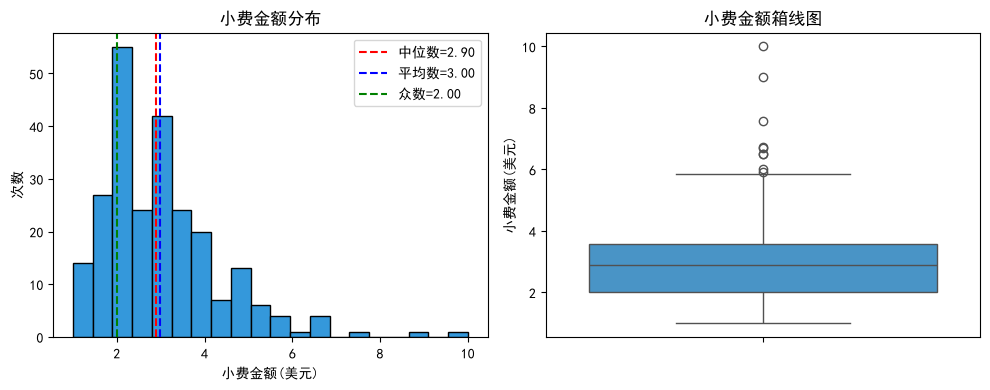

观察：小费金额呈右偏分布，大多集中在0-4美元之间。


In [ ]:
#左边是小费金额的直方图，右边是箱线图，插入了几条线，中位数，均值，众数
# 设置图表字体为黑体（固定通用）
plt.rcParams["font.family"] = ["SimHei"]
#解决图表负号显示异常（固定通用）
plt.rcParams["axes.unicode_minus"] = False
fig, axes = plt.subplots(1, 2, figsize=(10, 4))#一行二列，10x4英寸
#axes为包含两个子图对象的数组
axes[0].hist(tips['tip'], bins=20, color='#3498db', edgecolor='black')
axes[0].axvline(tips['tip'].median(), color='red', linestyle='--', label=f'中位数={tips["tip"].median():.2f}')
axes[0].axvline(tips['tip'].mean(), color='blue', linestyle='--', label=f'平均数={tips["tip"].mean():.2f}')
axes[0].axvline(tips['tip'].mode()[0], color='green', linestyle='--', label=f'众数={tips["tip"].mode()[0]:.2f}')
axes[0].set_xlabel('小费金额(美元)')
axes[0].set_xlabel('小费金额(美元)')
axes[0].set_ylabel('次数')
axes[0].set_title('小费金额分布')
axes[0].legend()#显示图例

sns.boxplot(data=tips, y='tip', color='#3498db', ax=axes[1])
axes[1].set_title('小费金额箱线图')
axes[1].set_ylabel('小费金额(美元)')
plt.tight_layout()#调整子图间距，左右不重叠
plt.savefig('output/tip_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("观察：小费金额呈右偏分布，大多集中在0-4美元之间。")

### 4.2 总消费与小费关系（散点图）


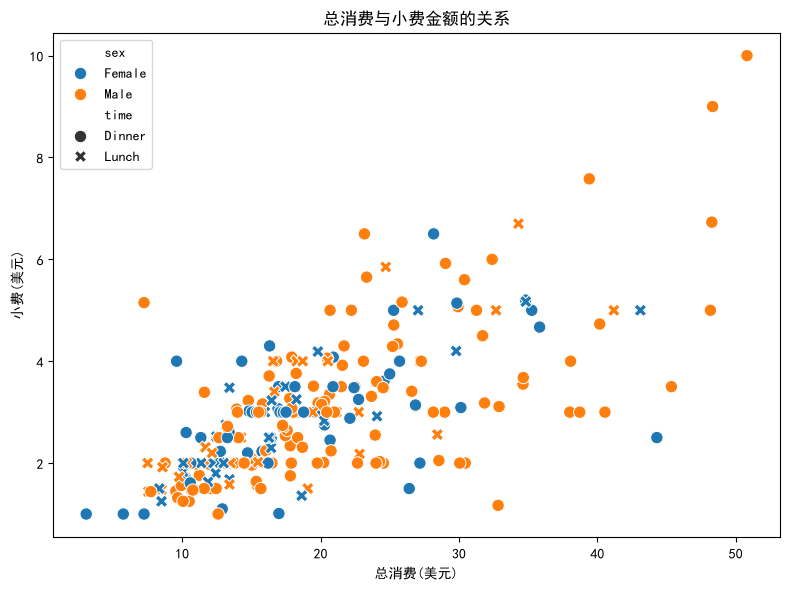

观察：总消费越高，小费金额总体呈上升趋势。


In [ ]:
# 散点图，横坐标是总小费，纵坐标是小费，不同颜色是性别，不同形状是就餐时间
# 能看出是成正比的关系
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', style='time', s=80)
plt.title('总消费与小费金额的关系')#hue为按照sex涂颜色，style为按照时间区分形状
plt.xlabel('总消费(美元)')
plt.ylabel('小费(美元)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('output/bill_vs_tip.png', dpi=150, bbox_inches='tight')
plt.show()
print("观察：总消费越高，小费金额总体呈上升趋势。")

### 4.3 性别与小费关系（柱状图，箱线图）


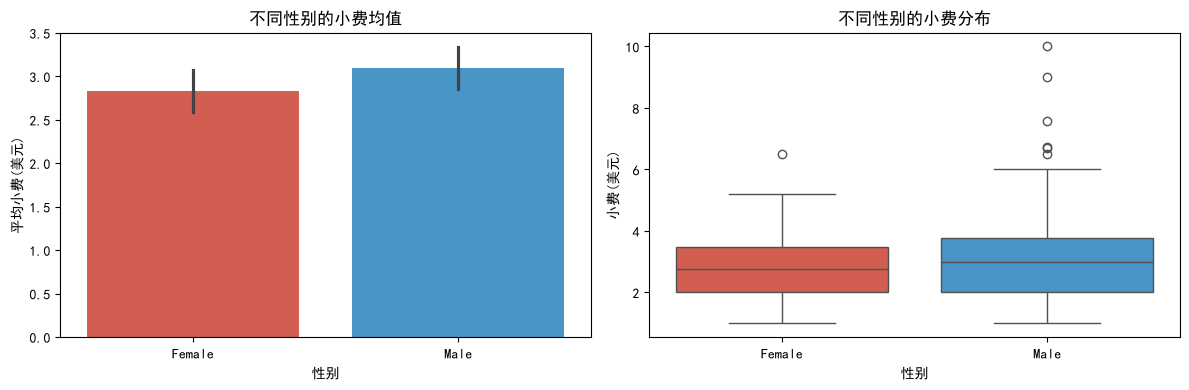

观察：男性顾客的小费略高于女性，但差异不大。


In [ ]:
#性别和小费的关系，做的柱状图和柱状图和箱线图，男性偏高
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#3498db']

sns.barplot(data=tips, x='sex', y='tip', palette=colors, ax=axes[0])
axes[0].set_title('不同性别的小费均值')#palette颜色，ax为位置
axes[0].set_xlabel('性别')
axes[0].set_ylabel('平均小费(美元)')

sns.boxplot(data=tips, x='sex', y='tip', palette=colors, ax=axes[1])
axes[1].set_title('不同性别的小费分布')
axes[1].set_xlabel('性别')
axes[1].set_ylabel('小费(美元)')
plt.tight_layout()#自动调整布局，别干一起
plt.savefig('output/gender_tip.png', dpi=150, bbox_inches='tight')
plt.show()
print("观察：男性顾客的小费略高于女性，但差异不大。")

### 4.4 用餐时间与小费（计数图，柱状图）


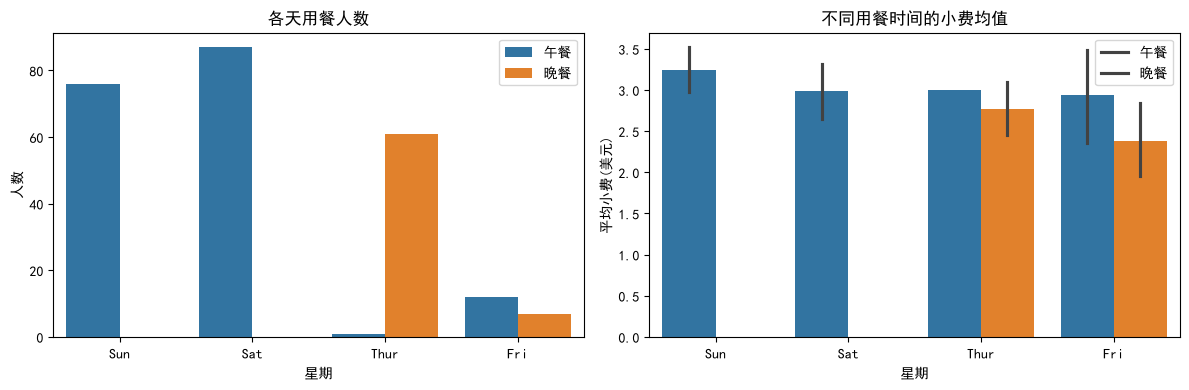

观察：周末用餐人数明显多于工作日，晚餐小费略高于午餐。


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#左边是计数图右边是柱状图
sns.countplot(data=tips, x='day', hue='time', ax=axes[0])
axes[0].set_title('各天用餐人数')#hue为按照时间涂色
axes[0].set_xlabel('星期')
axes[0].set_ylabel('人数')
axes[0].legend(['午餐', '晚餐'])#把英文标签换成中文

sns.barplot(data=tips, x='day', y='tip', hue='time', ax=axes[1])
axes[1].set_title('不同用餐时间的小费均值')
axes[1].set_xlabel('星期')
axes[1].set_ylabel('平均小费(美元)')
axes[1].legend(['午餐', '晚餐'])
plt.tight_layout()
plt.savefig('output/day_time_tip.png', dpi=150, bbox_inches='tight')
plt.show()
print("观察：周末用餐人数明显多于工作日，晚餐小费略高于午餐。")


### 4.5 吸烟与否与小费（计数图，柱状图）


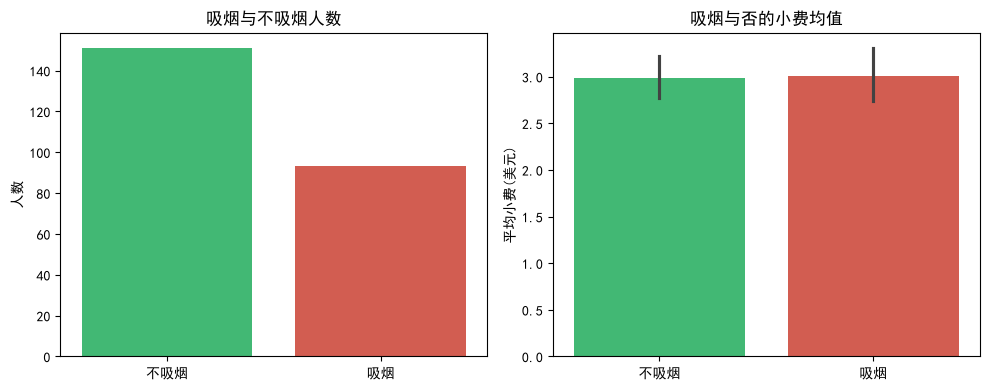

观察：不吸烟顾客人数较多，小费均值差异不大。


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
#左边是关于吸烟和不吸烟的人数计数图
#右边是吸烟的小费均值柱状图，说明吸烟对小费影响不大
sns.countplot(data=tips, x='smoker', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_xticklabels(['不吸烟', '吸烟'])
axes[0].set_title('吸烟与不吸烟人数')
axes[0].set_xlabel('')
axes[0].set_ylabel('人数')

sns.barplot(data=tips, x='smoker', y='tip', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xticklabels(['不吸烟', '吸烟'])
axes[1].set_title('吸烟与否的小费均值')
axes[1].set_xlabel('')
axes[1].set_ylabel('平均小费(美元)')
plt.tight_layout()
plt.savefig('output/smoker_tip.png', dpi=150, bbox_inches='tight')
plt.show()
print("观察：不吸烟顾客人数较多，小费均值差异不大。")


### 4.6 就餐人数与小费（计数图，柱状图）


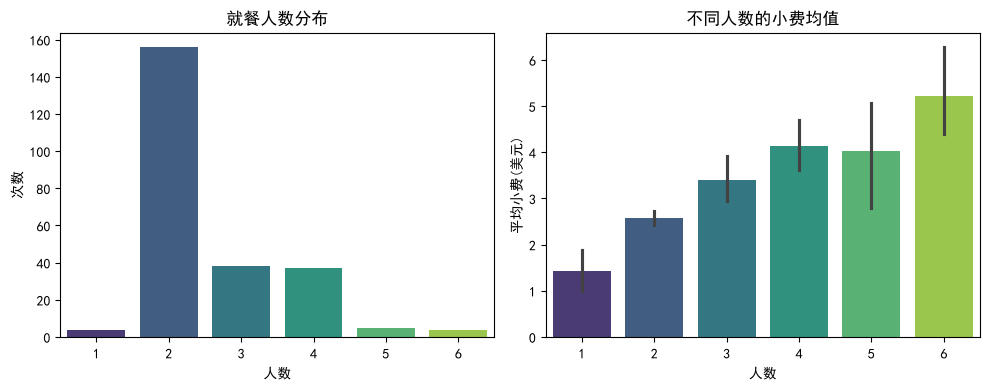

观察：2人就餐最为常见，随人数增加小费总体上升。


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=tips, x='size', palette='viridis', ax=axes[0])
axes[0].set_title('就餐人数分布')
axes[0].set_xlabel('人数')
axes[0].set_ylabel('次数')

sns.barplot(data=tips, x='size', y='tip', palette='viridis', ax=axes[1])
axes[1].set_title('不同人数的小费均值')
axes[1].set_xlabel('人数')
axes[1].set_ylabel('平均小费(美元)')
plt.tight_layout()
plt.savefig('output/party_size_tip.png', dpi=150, bbox_inches='tight')
plt.show()
print("观察：2人就餐最为常见，随人数增加小费总体上升。")


### 4.7 相关性热力图


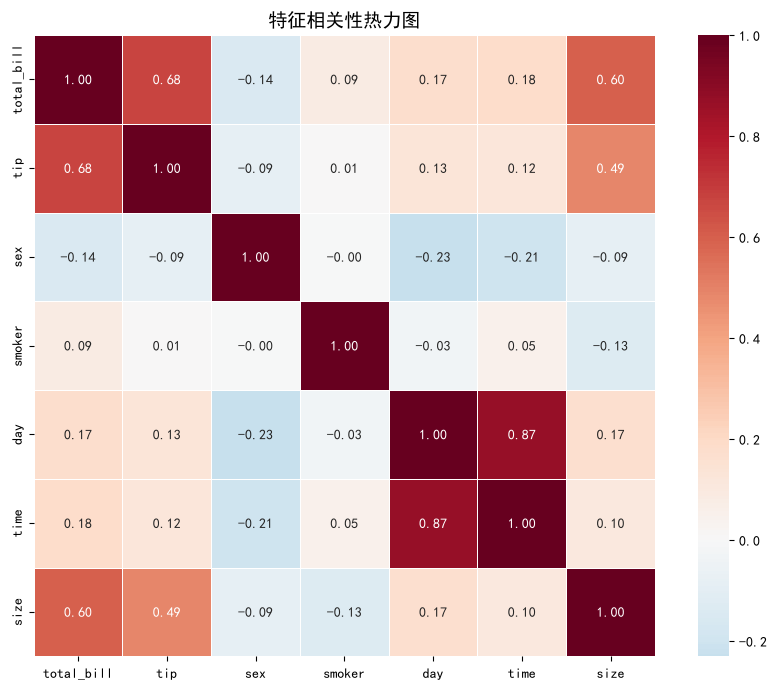

观察：总消费与小费的相关性最强，就餐人数也与小费正相关。


In [ ]:
# 将分类变量转为数值用于计算相关性，把字符串类型的数据变成数值
tips_corr = tips.copy()#把数据集拷贝一下
tips_corr['sex'] = tips_corr['sex'].map({'Male': 0, 'Female': 1})
tips_corr['smoker'] = tips_corr['smoker'].map({'No': 0, 'Yes': 1})
tips_corr['day'] = tips_corr['day'].map({'Thur': 0, 'Fri': 1, 'Sat': 2, 'Sun': 3})
tips_corr['time'] = tips_corr['time'].map({'Lunch': 0, 'Dinner': 1})

plt.figure(figsize=(9, 7))
sns.heatmap(tips_corr.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
#tips_corr.corr()数据源，annot显示数字，cmap颜色映射，fmt保留两位小数，square正方形格子
plt.title('特征相关性热力图', fontsize=14)
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("观察：总消费与小费的相关性最强，就餐人数也与小费正相关。")


## 6. 特征工程与数据预处理


### 5.1 创建分类目标


In [ ]:
# 以小费中位数为界，创建二分类目标变量，低于中位数为0，高于为1
median_tip = tips['tip'].median()
tips['tip_class'] = (tips['tip'] > median_tip).astype(int)
#比较完之后的到一个布尔序列，然后转数值0,1，新增一列
print(f"小费中位数: {median_tip:.2f} 美元")
print(f"\n分类目标分布:")
print(tips['tip_class'].value_counts())#统计每个类型有多少数据
print(f"高小费(>={median_tip:.2f}): {(tips['tip_class']==1).sum()} 条")
print(f"低小费(<{median_tip:.2f}): {(tips['tip_class']==0).sum()} 条")


小费中位数: 2.90 美元

分类目标分布:
tip_class
0    122
1    122
Name: count, dtype: int64
高小费(>=2.90): 122 条
低小费(<2.90): 122 条


### 5.2 特征编码与分离


In [ ]:
# 选中特征
features = ['total_bill', 'sex', 'smoker', 'day', 'time', 'size']
X = tips[features].copy()
y = tips['tip_class']

# 编码分类变量
X['sex'] = X['sex'].map({'Male': 0, 'Female': 1})
X['smoker'] = X['smoker'].map({'No': 0, 'Yes': 1})
X['day'] = X['day'].map({'Thur': 0, 'Fri': 1, 'Sat': 2, 'Sun': 3})
X['time'] = X['time'].map({'Lunch': 0, 'Dinner': 1})

print(f"特征矩阵: {X.shape}")
print(f"目标变量: {y.value_counts().to_dict()}")
print(f"\n特征列: {X.columns.tolist()}")#把列名转换成列表并打印出来
X.head()


特征矩阵: (244, 6)
目标变量: {0: 122, 1: 122}

特征列: ['total_bill', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,sex,smoker,day,time,size
0,16.99,1,0,3,1,2
1,10.34,0,0,3,1,3
2,21.01,0,0,3,1,3
3,23.68,0,0,3,1,2
4,24.59,1,0,3,1,4


### 5.3 数据集划分与标准化


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"训练集: {X_train.shape[0]} 条样本")
print(f"测试集: {X_test.shape[0]} 条样本")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 用训练集的参数来标准化测试集
# 标准化（Standardization）的核心意义是：
# 消除特征之间的量纲影响，让每个特征在模型中"说话的分量"一样。
print("标准化完成！")


训练集: 170 条样本
测试集: 74 条样本
标准化完成！


## 7. 模型构建与评估


### 6.1 逻辑回归


In [ ]:
# 逻辑回归模型种子是43，最大迭代数是1000，用训练数据来预测，然后输出准确率
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("===== 逻辑回归结果 =====")
print(f"准确率: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred_lr, target_names=['低小费', '高小费']))
#classification_report分类模型评估报告

===== 逻辑回归结果 =====
准确率: 0.7432

分类报告:
              precision    recall  f1-score   support

         低小费       0.70      0.86      0.77        37
         高小费       0.82      0.62      0.71        37

    accuracy                           0.74        74
   macro avg       0.76      0.74      0.74        74
weighted avg       0.76      0.74      0.74        74



### 6.2 随机森林


In [ ]:
# 创建随机森林，用100棵决策树,导入训练集进行训练,输出准确率
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("===== 随机森林结果 =====")
print(f"准确率: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred_rf, target_names=['低小费', '高小费']))
#precision为准确率，recall为召回率，f1-score为调和平均。support为测试集真实样本数

===== 随机森林结果 =====
准确率: 0.7027

分类报告:
              precision    recall  f1-score   support

         低小费       0.71      0.68      0.69        37
         高小费       0.69      0.73      0.71        37

    accuracy                           0.70        74
   macro avg       0.70      0.70      0.70        74
weighted avg       0.70      0.70      0.70        74



### 6.3 模型对比


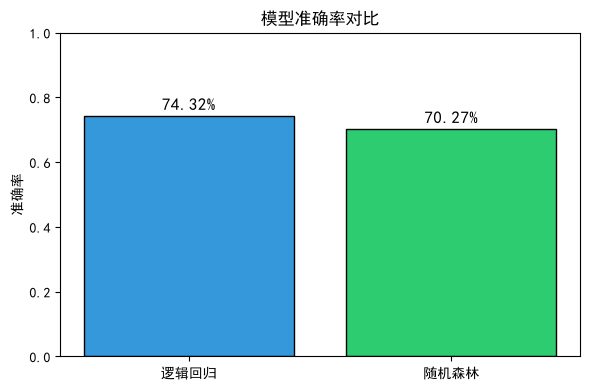

In [ ]:
#模型对比,看出逻辑回归准确率要高一点
models = ['逻辑回归', '随机森林']
accuracies = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'], edgecolor='black')
plt.ylim(0, 1)#y轴显示范围
plt.ylabel('准确率')
plt.title('模型准确率对比')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,#x坐标和y坐标
             f'{acc:.2%}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()#水平居中，底部对其
plt.savefig('output/model_compare.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 混淆矩阵


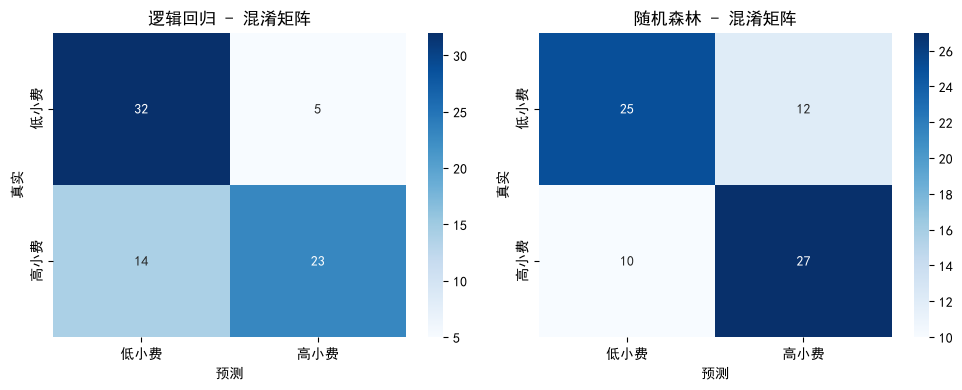

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            cmap='Blues', ax=axes[0], xticklabels=['低小费', '高小费'], yticklabels=['低小费', '高小费'])
axes[0].set_title('逻辑回归 - 混淆矩阵')
axes[0].set_xlabel('预测')
axes[0].set_ylabel('真实')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Blues', ax=axes[1], xticklabels=['低小费', '高小费'], yticklabels=['低小费', '高小费'])
axes[1].set_title('随机森林 - 混淆矩阵')
axes[1].set_xlabel('预测')
axes[1].set_ylabel('真实')

plt.tight_layout()
plt.savefig('output/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 随机森林调参 (Hyperparameter Tuning)

使用 GridSearchCV 对随机森林进行参数调优，寻找最佳参数组合，提升模型性能。

In [ ]:
# ===== 随机森林调参 =====
#先列出参数表,然后用五折交叉验证,准确率TPR为指标,训练540次
from sklearn.model_selection import GridSearchCV
print("=" * 50)
print("随机森林 GridSearchCV 调参")
print("=" * 50)

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print(f"最佳参数: {rf_grid.best_params_}")
print(f"最佳交叉验证得分: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
y_pred_rf_tuned = rf_best.predict(X_test_scaled)
rf_tuned_acc = accuracy_score(y_test, y_pred_rf_tuned)
print(f"调优后测试集准确率: {rf_tuned_acc:.4f}")
print()

随机森林 GridSearchCV 调参
最佳参数: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
最佳交叉验证得分: 0.7588
调优后测试集准确率: 0.7568



## 8. 模型融合 (Model Ensemble)

使用 VotingClassifier 将原始逻辑回归和调优后的随机森林进行融合（软投票），综合两个模型的优势，进一步提升预测性能。

模型融合 (VotingClassifier - 软投票)
融合模型测试集准确率: 0.7838

融合模型分类报告:
              precision    recall  f1-score   support

         低小费       0.78      0.78      0.78        37
         高小费       0.78      0.78      0.78        37

    accuracy                           0.78        74
   macro avg       0.78      0.78      0.78        74
weighted avg       0.78      0.78      0.78        74



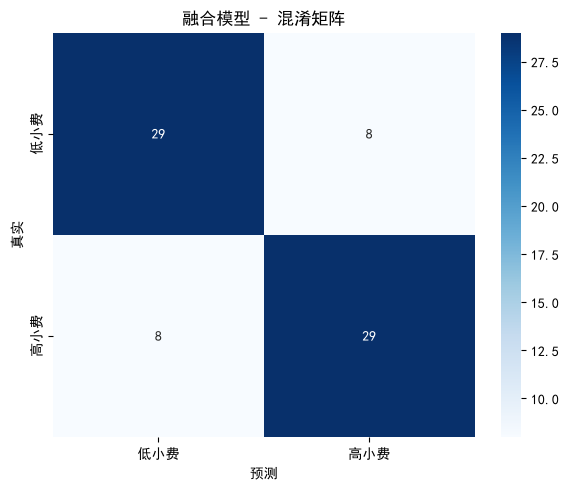


所有模型准确率对比
逻辑回归(原始)       : 0.7432
随机森林(调优)       : 0.7568
融合模型           : 0.7838


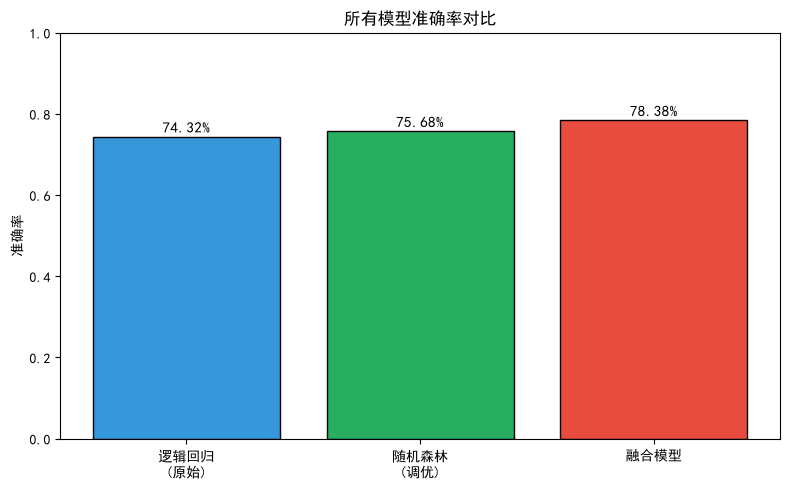


✅ 模型融合完成！融合模型综合了两个模型的优势。


In [ ]:
from sklearn.ensemble import VotingClassifier

# ===== VotingClassifier 软投票融合 =====
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),      # 原始逻辑回归
        ('rf', rf_best)  # 调优后的随机森林
    ],
    voting='soft'  # 软投票：用预测概率加权平均
)
voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = voting_clf.predict(X_test_scaled)
voting_acc = accuracy_score(y_test, y_pred_voting)
print(f"融合模型测试集准确率: {voting_acc:.4f}")

# 分类报告
print("\n融合模型分类报告:")
print(classification_report(y_test, y_pred_voting, target_names=['低小费', '高小费']))

# 融合模型混淆矩阵
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_voting), annot=True, fmt='d',
            cmap='Blues', xticklabels=['低小费', '高小费'], yticklabels=['低小费', '高小费'])
plt.title('融合模型 - 混淆矩阵')
plt.xlabel('预测')
plt.ylabel('真实')
plt.tight_layout()
plt.savefig('output/voting_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== 所有模型准确率对比 =====
print("\n" + "=" * 50)
print("所有模型准确率对比")
print("=" * 50)

models_all = ['逻辑回归\n(原始)', '随机森林\n(调优)', '融合模型']
acc_all = [
    accuracy_score(y_test, y_pred_lr),
    rf_tuned_acc,
    voting_acc
]

for name, acc in zip(['逻辑回归(原始)', '随机森林(调优)', '融合模型'], acc_all):
    print(f"{name:15s}: {acc:.4f}")

plt.figure(figsize=(8, 5))
colors_all = ['#3498db', '#27ae60', '#e74c3c']
bars = plt.bar(models_all, acc_all, color=colors_all, edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('准确率')
plt.title('所有模型准确率对比')
for bar, acc in zip(bars, acc_all):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('output/all_models_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 模型融合完成！融合模型综合了两个模型的优势。")

## 9. 特征重要性分析

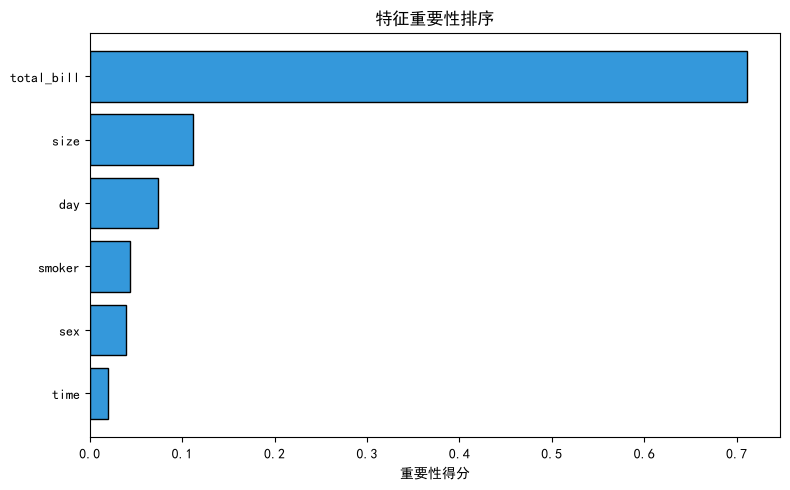

===== 特征重要性排序 =====
           特征       重要性
0  total_bill  0.711437
5        size  0.111480
3         day  0.074418
2      smoker  0.043231
1         sex  0.039351
4        time  0.020083


In [ ]:
# 用matplotlib画一个水平条形图,把每一个特征的重要性展示出来
importance = pd.DataFrame({
    '特征': features,
    '重要性': rf.feature_importances_
}).sort_values('重要性', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance.sort_values('重要性')['特征'],
         importance.sort_values('重要性')['重要性'],
         color='#3498db', edgecolor='black')
plt.xlabel('重要性得分')
plt.title('特征重要性排序')
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("===== 特征重要性排序 =====")
print(importance)

## 10. 总结与结论

### 主要发现

1. **总消费金额是影响小费的最关键因素**：消费越高，小费金额总体越高，两者呈较强的正相关关系。

2. **就餐人数也有显著影响**：就餐人数越多，小费总额越高，这与餐饮服务工作量增加相符。

3. **性别和时段影响较小**：男性小费略高于女性，晚餐小费略高于午餐，但差异不大。

4. **模型效果**：逻辑回归和随机森林对小费高低分类的准确率均较好，能够基于顾客特征有效预测小费水平。

### 不足与展望

- 数据集较小（仅244条），可能影响模型的泛化能力
- 缺少服务质量和顾客满意度等主观因素
- 未来可收集更多维度的数据（如菜品类型、等餐时间等）来优化模型
